In [1]:
import pandas as pd
import matplotlib.pyplot as plt
df = pd.read_csv("bank-full.csv", sep=';')
df.head()

,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,y
0,58,management,married,tertiary,no,2143,yes,no,unknown,5,may,261,1,-1,0,unknown,no
1,44,technician,single,secondary,no,29,yes,no,unknown,5,may,151,1,-1,0,unknown,no
2,33,entrepreneur,married,secondary,no,2,yes,yes,unknown,5,may,76,1,-1,0,unknown,no
3,47,blue-collar,married,unknown,no,1506,yes,no,unknown,5,may,92,1,-1,0,unknown,no
4,33,unknown,single,unknown,no,1,no,no,unknown,5,may,198,1,-1,0,unknown,no


In [2]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 45211 entries, 0 to 45210
Data columns (total 17 columns):
 #   Column     Non-Null Count  Dtype
---  ------     --------------  -----
 0   age        45211 non-null  int64
 1   job        45211 non-null  str  
 2   marital    45211 non-null  str  
 3   education  45211 non-null  str  
 4   default    45211 non-null  str  
 5   balance    45211 non-null  int64
 6   housing    45211 non-null  str  
 7   loan       45211 non-null  str  
 8   contact    45211 non-null  str  
 9   day        45211 non-null  int64
 10  month      45211 non-null  str  
 11  duration   45211 non-null  int64
 12  campaign   45211 non-null  int64
 13  pdays      45211 non-null  int64
 14  previous   45211 non-null  int64
 15  poutcome   45211 non-null  str  
 16  y          45211 non-null  str  
dtypes: int64(7), str(10)
memory usage: 5.9 MB


In [3]:
df['y'].value_counts()

y
no     39922
yes     5289
Name: count, dtype: int64

In [4]:
conversion_rate=df['y'].value_counts(normalize=True)*100
print(conversion_rate)

y
no     88.30152
yes    11.69848
Name: proportion, dtype: float64


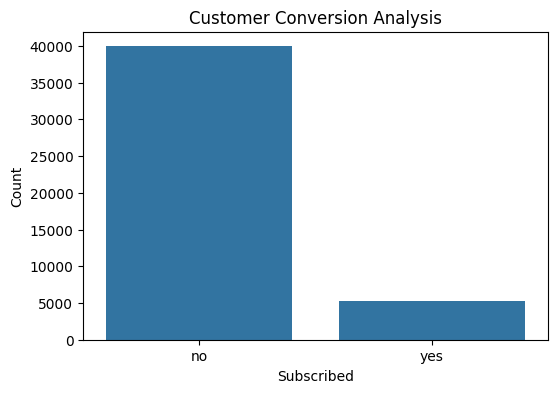

In [5]:
import seaborn as sns

plt.figure(figsize=(6,4))

sns.countplot(x='y', data=df)

plt.title("Customer Conversion Analysis")
plt.xlabel("Subscribed")
plt.ylabel("Count")

plt.show()

In [6]:
df['contact'].value_counts()

contact
cellular     29285
unknown      13020
telephone     2906
Name: count, dtype: int64

In [7]:
channel_conversion=pd.crosstab(df['contact'],df['y'])
print(channel_conversion)

y             no   yes
contact               
cellular   24916  4369
telephone   2516   390
unknown    12490   530


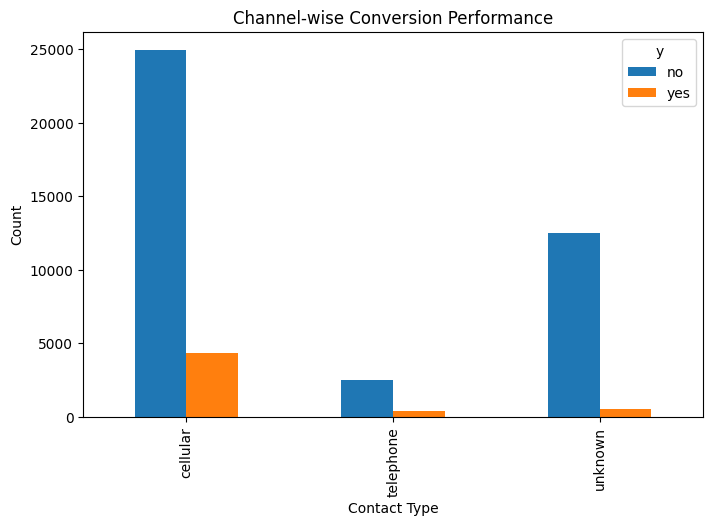

In [8]:
channel_conversion.plot(kind='bar', figsize=(8,5))

plt.title("Channel-wise Conversion Performance")
plt.xlabel("Contact Type")
plt.ylabel("Count")

plt.show()

In [9]:
total_leads = len(df)

converted_customers = len(df[df['y'] == 'yes'])

not_converted = len(df[df['y'] == 'no'])

print("Total Leads:", total_leads)
print("Converted Customers:", converted_customers)
print("Lost Leads:", not_converted)

Total Leads: 45211
Converted Customers: 5289
Lost Leads: 39922


In [10]:
funnel_data = {
    'Stage': ['Total Leads', 'Converted Customers'],
    'Count': [total_leads, converted_customers]
}

funnel_df = pd.DataFrame(funnel_data)

funnel_df

,Stage,Count
0,Total Leads,45211
1,Converted Customers,5289


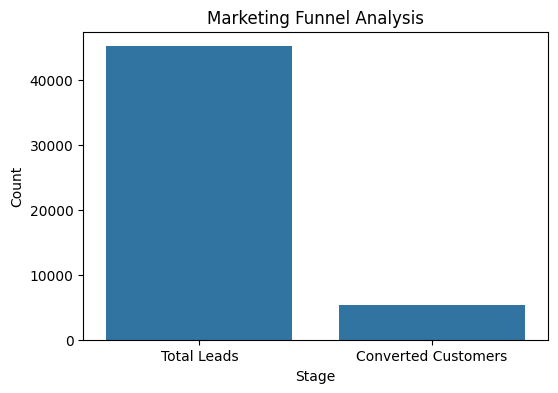

In [11]:
plt.figure(figsize=(6,4))

sns.barplot(x='Stage', y='Count', data=funnel_df)

plt.title("Marketing Funnel Analysis")

plt.show()

# Business Insights

1. A large number of customers were contacted during the campaign, but only a smaller group actually subscribed to the service.

2. Customers contacted through cellular communication responded better compared to other contact methods.

3. The analysis shows that there is room to improve how potential customers are targeted during marketing campaigns.

4. Many leads were lost before the final conversion stage, indicating a noticeable drop in the marketing funnel.

5. Better communication and follow-up strategies could help increase customer conversions in future campaigns.


# Recommendations

- More focus can be given to communication channels that bring better customer responses.

- Marketing campaigns should be more targeted to reach customers who are more likely to subscribe.

- Regular follow-ups may help reduce the number of lost leads during the conversion process.

- Personalized offers and better customer engagement strategies can improve overall conversion rates.

- Tracking funnel performance regularly can help identify weak stages and improve future campaign results.
